In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# import database / data

In [2]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
            SELECT name
            FROM sqlite_master
            WHERE type='table'
"""
tables = pd.read_sql(sql_query, conn) 

# Create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
# Print tables names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get Column information
    columns_query = f"PRAGMA table_info({table_name});" #PRAGMA is special type of command that helps to get information from tables
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())
    print("----------------------------------------------------------")

#Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']
----------------------------------------------------------

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']
----------------------------------------------------------

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']
----------------------------------------------------------


In [4]:
# 2. Data cleaning

In [5]:
df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
# a. Rename col - name 
# b. Drop col - intrest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values - country

In [8]:
 # a. Rename col - name and customerid
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)


df_db_customer.rename(columns = {'customerid' : 'customer_id'}, inplace = True)
df_db_customer


,customer_id,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [9]:
# b.drop columns - interest and pincode
# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
df_db_customer.drop(columns = ['interests', 'pincode'], inplace = True)


In [10]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [11]:
# c. change data type - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [12]:
# d. data standardization - gender
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})


In [13]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [14]:
# e. fix missing values - country

df_db_customer[df_db_customer['country'].isna()]  #isna() is function that check null value 

,customer_id,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [15]:
# Country and state - unique value pair

state_country_mapping  = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [16]:
df_db_customer[df_db_customer['country'].isna()]

,customer_id,customer_name,country,state,gender,dob


In [17]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [18]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [19]:
df_db_subscription.rename(columns = {'customerid' : 'customer_id'}, inplace = True)
# All dates datatype change in date format

date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [20]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [21]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [22]:
df_db_support.drop(columns= ['col_1', 'comment'], inplace = True)

In [23]:
df_db_support.rename(columns = {'customerid' : 'customer_id'}, inplace = True)
df_db_support['complaint_date']= pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [24]:
# 3. Feature Engineering and Data Analyasis


In [25]:
 df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [26]:
df_db_subscription.head()

,customer_id,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [27]:
# first fix support table duplicates then merge 
df= (df_db_subscription
            .merge(df_db_customer, on = 'customer_id', how= 'left')
            .merge(df_db_support, on = 'customer_id', how= 'left'))
    

In [28]:
df_db_subscription.shape # check rows and colums in table

(21, 12)

In [29]:
df.shape

(23, 20)

In [30]:
df_db_subscription['customer_id'].nunique()

21

In [31]:
df_db_customer['customer_id'].nunique()

21

In [32]:
df_db_support['customer_id'].nunique()

7

In [33]:
df_db_support['customer_id'].size

9

In [34]:
df_db_support

,customer_id,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [35]:
df_db_support['complaint_count'] = df_db_support.groupby('customer_id')['customer_id'].transform('count')

In [36]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customer_id', keep= 'last')

In [37]:
df_db_support['customer_id'].size

7

In [38]:
df.head(3)

,customer_id,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0


In [39]:
#merge df
df= (df_db_subscription
            .merge(df_db_customer, on = 'customer_id', how= 'left')
            .merge(df_db_support, on = 'customer_id', how= 'left'))
    

In [40]:
df.shape

(21, 21)

In [41]:
df.head(3)

,customer_id,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN


In [42]:
df.to_csv('exported_churn_data.csv', index=False)

In [43]:
# Data Analysis

In [44]:
# 1. Churn Rate 

In [45]:
df.columns

Index(['customer_id', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [46]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [47]:
df.head(3)

,customer_id,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN


In [48]:
# 2. Retention Rate 
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [49]:
# 3. Churn by Plan type
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print( churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [50]:
# 4. a. Churn by state + sum(revenue) & count of users ....homeWork**
# 4. b. Churn by subscription type + sum(revenue) & count of users.....homeWork**

In [51]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU =', round(arpu,2))

ARPU = 18.85


In [52]:
# homework - calculate customer age 

In [53]:
# 6.  Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today  = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),
    
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) =", round(avg_tenure),0)
    

Avg Tenure (Days) = 1526 0


In [54]:
# 7  Revenue at risk -revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", revenue_at_risk)

Revenue at Risk (Rs 'K') = 73.94


In [55]:
# 8. Esclation Rate 
esclation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(esclation_rate, 2), "%")

Esclation Rate =  19.05 %


In [56]:
# 9. Avg Complaint per User
avg_complaints = df['complaint_count'].sum() / df['customer_id'].nunique()
print ("Avg Complaints per User = ", round(avg_complaints, 2))

Avg Complaints per User =  0.43


In [57]:
# 10 Correlation Escalation vs churn 
# # Check original values first
# print(df['escalations'].value_counts())

# # Encode Y/N → 1/0
# df['escalations'] = df['escalations'].map({'Y': 1, 'N': 0})

# # Check encoded values
# print(df['escalations'].value_counts())

# # Correlation
# corr_df = df[['escalations', 'churn_flag']].dropna()

# correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("Correlation between escalation vs churn =", round(correlation, 2))

Correlation between escalation vs churn = 0.77


In [58]:
# 11. Churn risk - create a column using existing col
condition = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(condition, choices, default= 'unknow')

In [59]:
df.head()

,customer_id,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1991.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1376.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2666.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [60]:
# 4. visualization using matplotlib

In [61]:
df_visual = df.copy()

In [62]:
df_visual.columns

Index(['customer_id', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

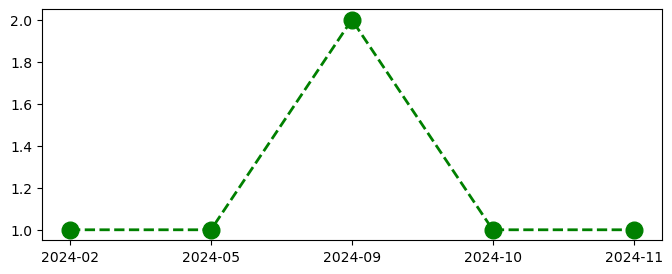

In [63]:
# 4.1 Monthly Churn Trend (time series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)

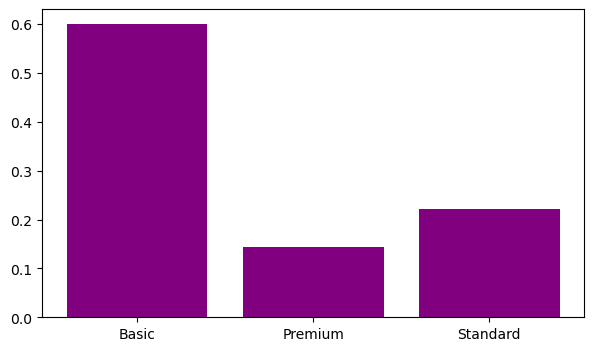

In [64]:
# 4.2 Churn by plan type 
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# color = ['yellow', 'purple', 'blue'] # clors for bar
# colors= plt.cm.Set2(np.linspace(0,1, len(churn_plan))) # it takes random colors 
plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = 'purple')

plt.show()

<BarContainer object of 9 artists>

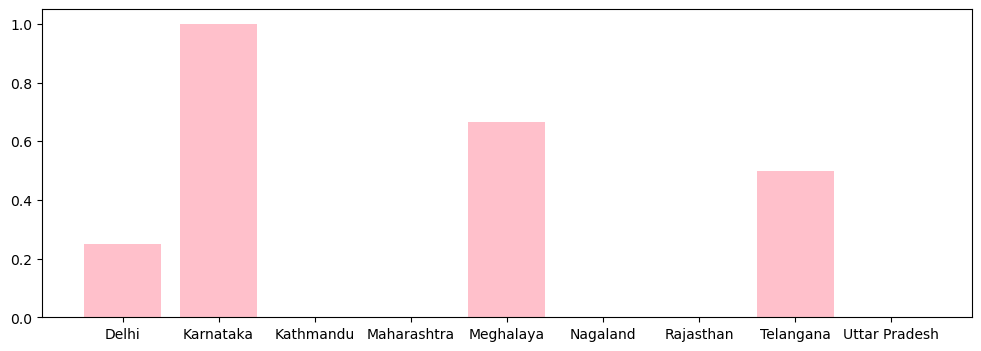

In [65]:
# 4.3 Churn by State
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color = 'pink')

<BarContainer object of 2 artists>

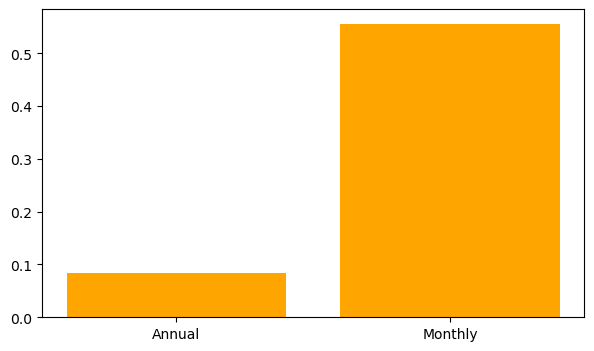

In [66]:
# 4.4 Churn by Contract type

churn_plan = df_visual.groupby('contract_type')['churn_flag'].mean()

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = 'orange')

<BarContainer object of 2 artists>

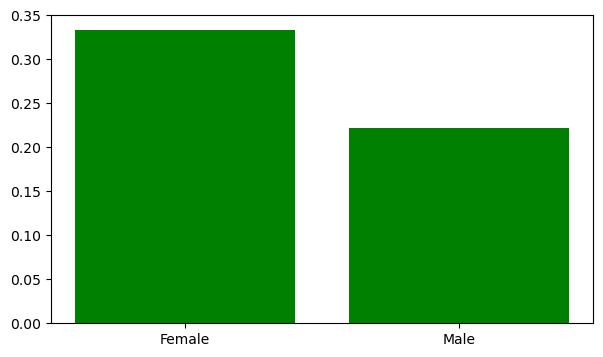

In [67]:
# 4.3 Churn by Gender
churn_plan = df_visual.groupby('gender')['churn_flag'].mean()

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = 'green')

In [68]:
# Visualisation using Seaborn

In [69]:
# encoding - conver str to numeric so that we can find corr between features
df_visual.columns

Index(['customer_id', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [70]:
df_encoded =df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

In [71]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [72]:
import warnings
warnings.filterwarnings("ignore")

In [73]:
# incoorect method of encoding - as numbers are not assigned based on priority
# encode the col String to numuric code
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

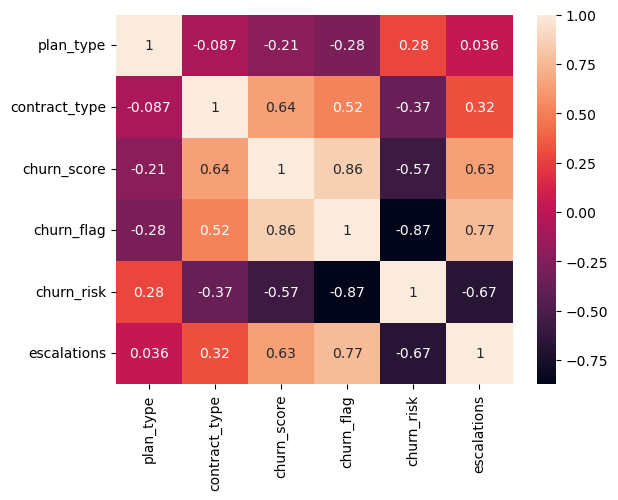

In [74]:
# Heatmap (correlation matrix)
       #---> Heatmap only applies on numeric values 
        #---> thats why first String convert into numeric values
sns.heatmap(df_encoded.corr(), annot=True)

In [75]:
# Note :
#         0 to 1 --> Positive correlation
#         -1 to 0 --> Negative correlation 

In [76]:

df_visual['plan_type'].unique()

array(['Standard', 'Premium', 'Basic'], dtype=object)

In [77]:
# Correct method of encoding - based on priority 
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mapping = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
}

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [78]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


<Axes: >

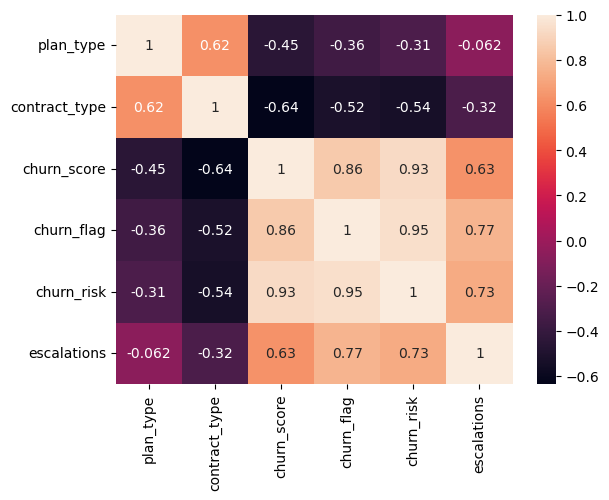

In [79]:
# Heatmap (correlation matrix)
    
sns.heatmap(df_encoded.corr(), annot=True)

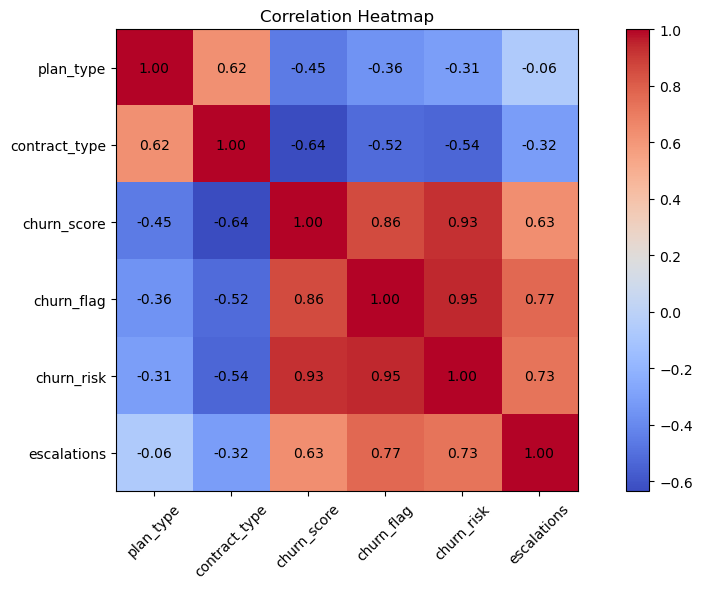

In [80]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') #Heatmap

fig.colorbar(cax) # add colorbar

#Axis lables
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
   
ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

#Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # title
plt.tight_layout()
plt.show()

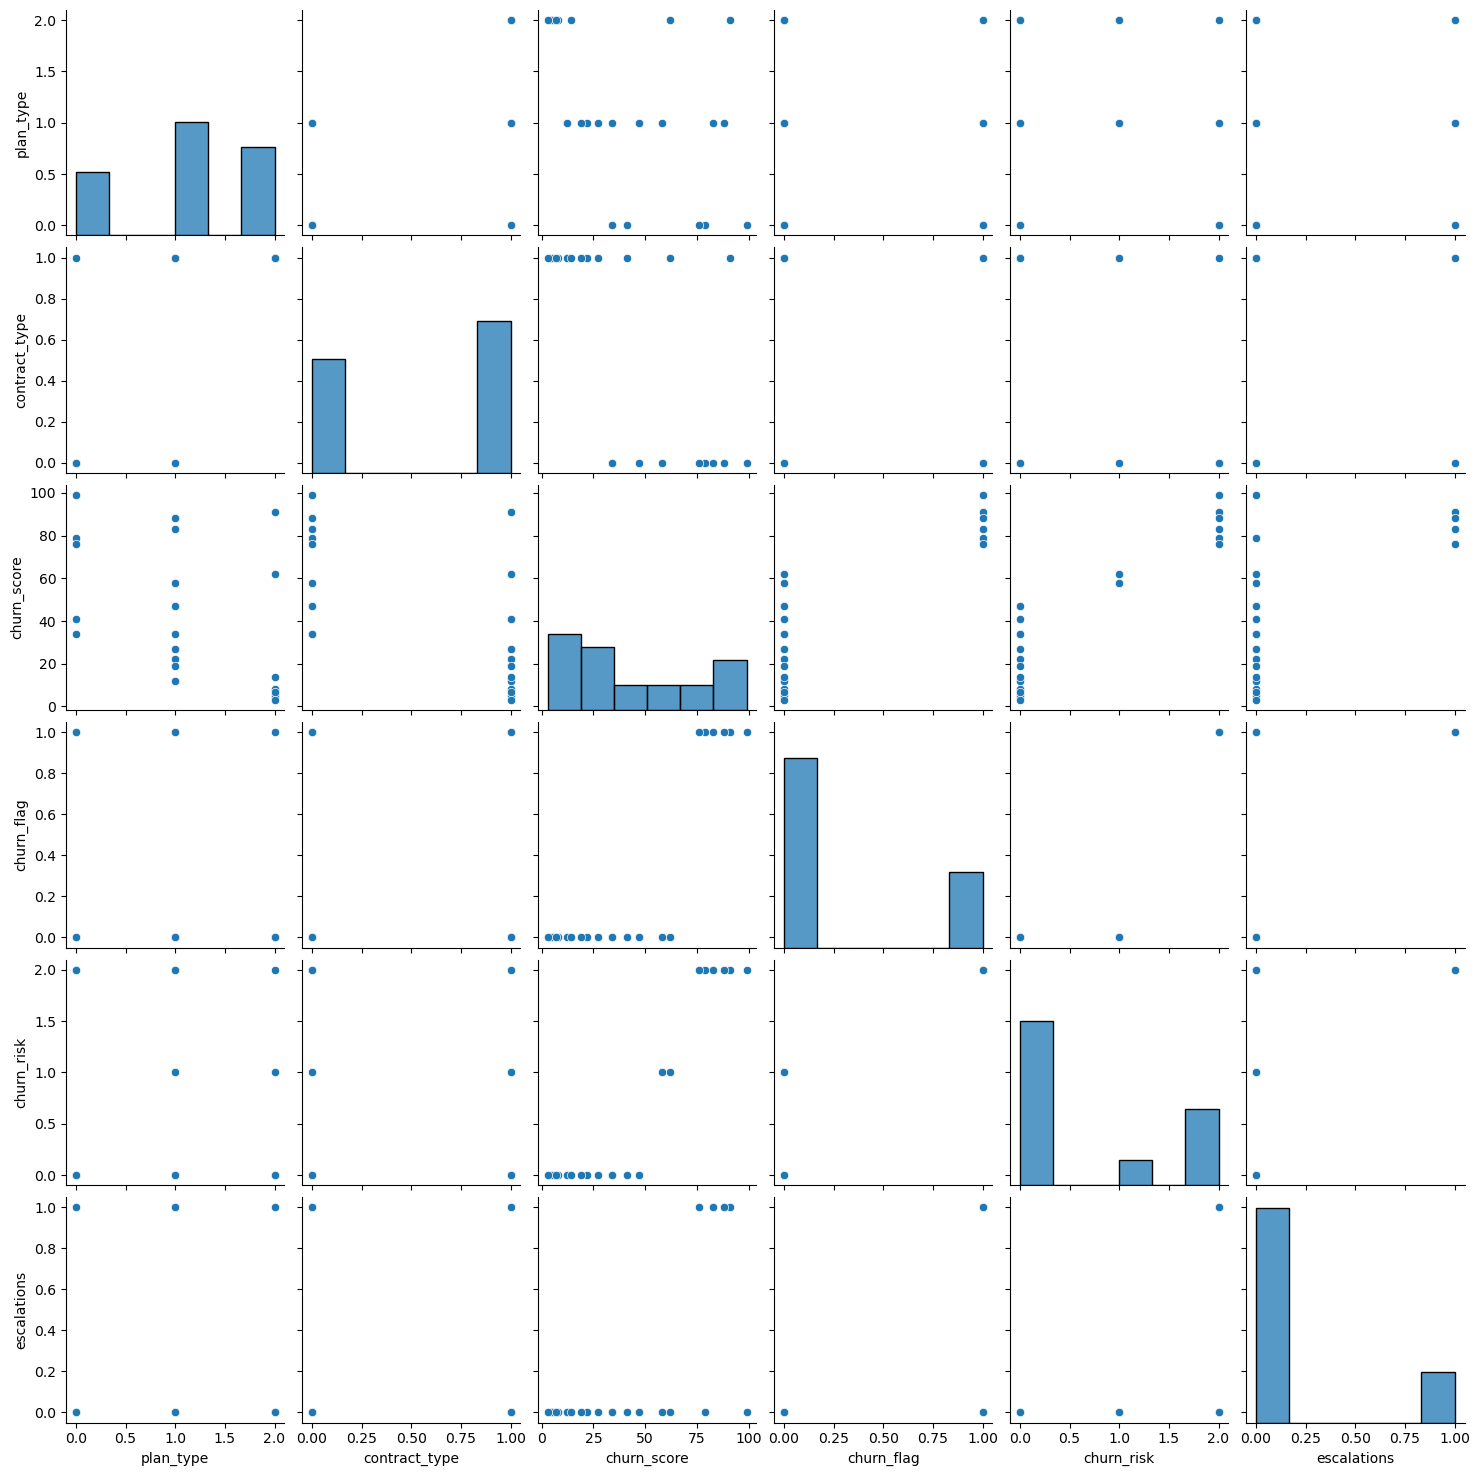

In [81]:
# paitplot
sns.pairplot(df_encoded)

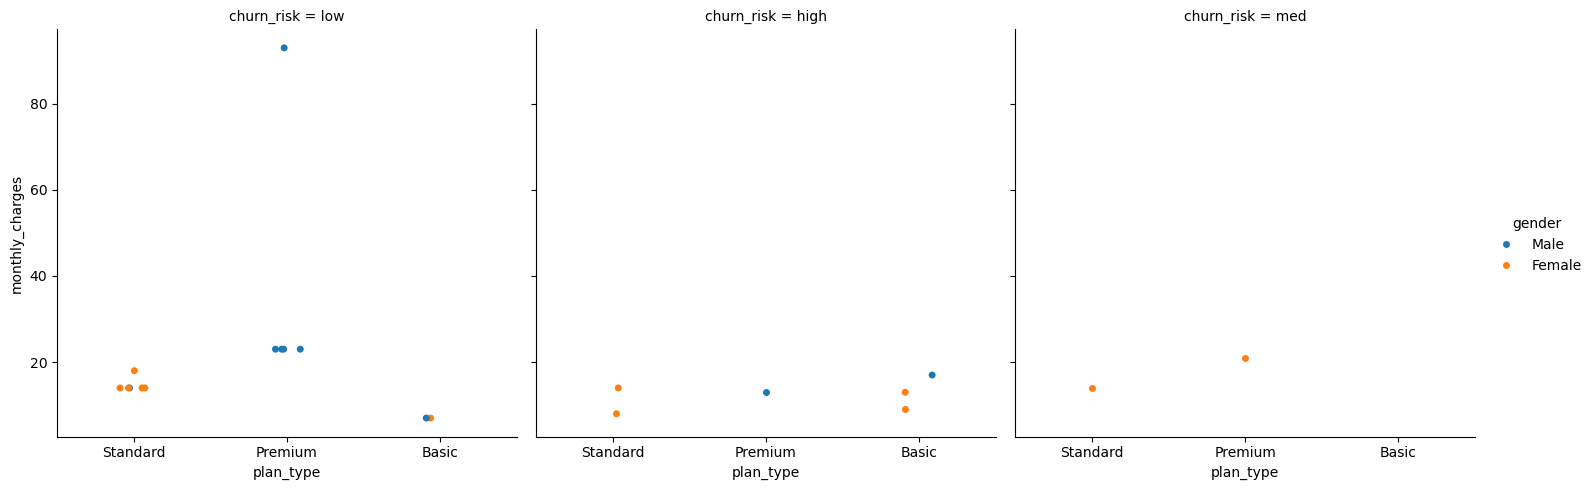

In [82]:
# catplot/Facegrid plot'
        #multidimensional comparision
sns.catplot(data=df_visual,
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk')

In [83]:
df.columns

Index(['customer_id', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [84]:
df.head(2)

,customer_id,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1991.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high


In [85]:
# Pivot Table 


In [86]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [87]:
df_visual.columns

Index(['customer_id', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [88]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customer_id','churn_flag'], 
    aggfunc = {
        'monthly_charges': 'sum',
        'customer_id': 'nunique',
        'churn_flag' : 'mean'
        }
)

,churn_flag,customer_id,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [89]:
# Working with SQL in python (pandas)

In [90]:
#create db in sql
conn = sqlite3.connect('test_database.sqlite')

#tables details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, BUDGET INTEGER )")

# commit and save
conn.commit()

In [96]:
# insert data

cursor = conn.cursor()

#write sql query to insert records in sql
cursor.execute(
    """
        INSERT INTO users VALUES 
            ('Madhav', 'India', 5000),
            ('Rishab', 'Germany', 2500),
            ('Vaishanvi', 'India', 3500)    
    """
)

# commit and save
conn.commit()

print("Data Inserted successfully")

Data Inserted successfully


In [98]:
# Check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM users"""
df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,BUDGET
0,Madhav,india,5000
1,Rishab,Germany,2500
2,Vaishanvi,India,3500
3,Madhav,India,5000
4,Rishab,Germany,2500


In [100]:
#aggregation
query = """
        SELECT country, sum(budget) as total_budget
        FROM users
        GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,5000
1,India,12000
2,india,5000


In [101]:
# always close connection with db once the task is over
conn.close()